## Импорт библиотек и загрузка данных

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.computational_functions import calc_num_cols

In [47]:
primary_df = pd.read_csv("../data/processed/after_eda.csv", parse_dates=["date"])
primary_df.head(5)

,age,sex,date,fall_asleep,wake_up,sleep_quality,awakenings,dream_remembered,dream_colored,amount_of_coffee,...,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed,sleep_duration,sleep_hours,participant_id
0,45 лет и более,1,2026-09-13,0 days 23:30:00,0 days 06:45:00,3,3,1,color,1,...,0,4,2,1,0,3,1,0 days 07:15:00,7.250000,11
1,до 18 лет,1,2026-09-13,0 days 02:00:00,0 days 10:00:00,3,1,0,NaN,1,...,0,5,0,0,0,8,0,0 days 08:00:00,8.000000,19
2,от 18 до 30 лет,1,2026-09-13,0 days 00:00:00,0 days 08:13:00,4,0,0,NaN,0,...,0,2,4,0,0,8,1,0 days 08:13:00,8.216667,8
3,45 лет и более,0,2026-09-13,0 days 23:00:00,0 days 06:20:00,3,3,0,NaN,1,...,0,2,3,1,0,3,1,0 days 07:20:00,7.333333,17
4,от 18 до 30 лет,0,2026-09-13,0 days 03:00:00,0 days 10:25:00,5,0,1,color,10,...,1,2,1,0,1,3,1,0 days 07:25:00,7.416667,16


In [4]:
df = primary_df.copy()

## Панельная структура данных

### Формализация структуры данных

In [6]:
df = df.sort_values(["participant_id", "date"])
df["observation_number"] = df.groupby(by="participant_id").cumcount() + 1

df[["date", "observation_number"]].head(5)

,date,observation_number
15,2026-09-13,1
51,2026-09-14,2
82,2026-09-15,3
117,2026-09-16,4
144,2026-09-17,5


In [7]:
person_day = df.groupby(by=["participant_id"]).size().reset_index(name='count')

print("Доля пройденных дней опроса, %")
person_proportion = (person_day.value_counts(normalize=True, subset="count") * 100).reset_index(name="proportion")
person_proportion

Доля пройденных дней опроса, %


,count,proportion
0,12,60.526316
1,11,18.421053
2,7,5.263158
3,13,5.263158
4,4,2.631579
5,1,2.631579
6,8,2.631579
7,14,2.631579


In [8]:
print(f"Доля участников с полным циклом опроса (12 дней): {person_proportion[person_proportion["count"] >= 12]["proportion"].sum().round(2)}%")

Доля участников с полным циклом опроса (12 дней): 68.42%


In [9]:
n_obs = df.groupby("participant_id").size()
print(f"Количество участников с полным циклом наблюдений: {(n_obs >= 12).sum()}")

Количество участников с полным циклом наблюдений: 26


### Таблица балансировки панели

In [10]:
balance_table = pd.DataFrame({
    "Наблюдений на участника": n_obs.value_counts().sort_index(),
    "Доля участников, %": (n_obs.value_counts(normalize=True).sort_index() * 100).round(1)
}).reset_index().rename(columns={"index": "Количество наблюдений"})

balance_table

,Количество наблюдений,Наблюдений на участника,"Доля участников, %"
0,1,1,2.6
1,4,1,2.6
2,7,2,5.3
3,8,1,2.6
4,11,7,18.4
5,12,23,60.5
6,13,2,5.3
7,14,1,2.6


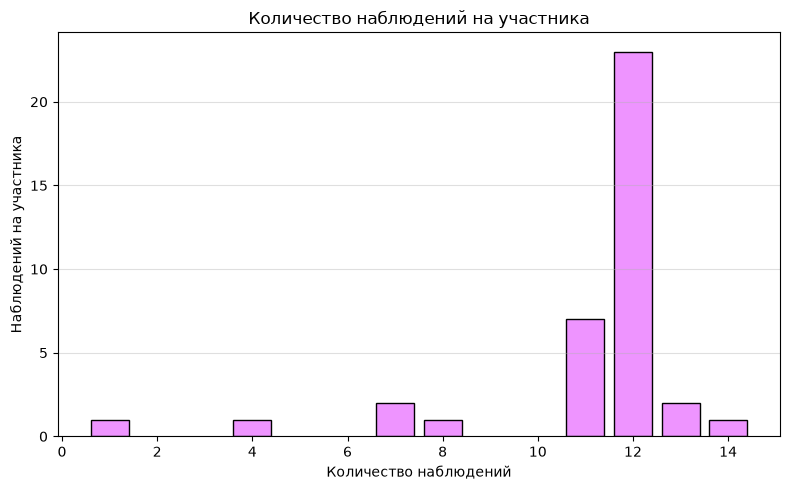

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(balance_table["Количество наблюдений"], balance_table["Наблюдений на участника"], edgecolor="black", color="#ee94ff")

ax.set_title("Количество наблюдений на участника")
ax.set_xlabel("Количество наблюдений")
ax.set_ylabel("Наблюдений на участника")

ax.grid(True, axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

### Статистика дат первого и последнего прохождения опроса и пропусков календарных дней

In [12]:
# 12 дней — запланированное количество наблюдений в дизайне исследования
date_range = df.groupby("participant_id")["date"].min().reset_index(name="first_date")
date_range["last_date"] = df.groupby("participant_id")["date"].transform("max")
date_range = date_range.set_index("participant_id")
date_range["actual_days"] = n_obs
date_range["missing_days"] = date_range["actual_days"].apply(lambda x: 12 - x if x <= 12 else 0)

date_range.head(5)

,first_date,last_date,actual_days,missing_days
participant_id,,,,
1,2026-09-13,2026-09-24,12,0
2,2026-09-14,2026-09-24,4,8
3,2026-09-13,2026-09-24,12,0
4,2026-09-13,2026-09-24,12,0
5,2026-09-14,2026-09-24,11,1


In [13]:
print(f"Среднее число пропущенных дней: {date_range["missing_days"].mean():.2f}")
print(f"Медианное число пропущенных дней: {date_range["missing_days"].median():.2f}")

print(f"Количество участников с пропусками: {date_range[date_range["missing_days"] > 0]["missing_days"].count()}")

Среднее число пропущенных дней: 1.05
Медианное число пропущенных дней: 0.00
Количество участников с пропусками: 12


### Просмотр людей с календарными разрывами

In [14]:
def count_calendar_gaps(group):
    dates = group["date"].sort_values()
    gaps = (dates.diff().dt.days > 1).sum()
    return gaps

calendar_gaps = df.groupby("participant_id").apply(count_calendar_gaps)
print(f"Участников с календарными разрывами: {(calendar_gaps > 0).sum()}")
print(f"Среднее число разрывов на участника: {calendar_gaps.mean():.2f}")

Участников с календарными разрывами: 7
Среднее число разрывов на участника: 0.24


In [15]:
# Удаляем участника с 1 наблюдением
df = df.groupby(by="participant_id").filter(lambda x: len(x) > 1)

### Описательная статистика по участникам

|Признак|Тип|Как анализировать|
|-------|---|-----------------|
|age	|Constant	|Только Between|
|sex	|Constant	|Только Between|
|sleep_hours	|Time-varying	|Within + Between|
|sleep_quality	|Time-varying	|Within + Between|
|awakenings	|Time-varying	|Within + Between|
|amount_of_coffee	|Time-varying	|Within + Between|
|amount_of_coffee_after16	|Time-varying	|Within + Between|
|stress_level	|Time-varying	|Within + Between|
|hours_of_physical_activity	|Time-varying	|Within + Between|
|screen_time	|Time-varying	|Within + Between|
|alcohol	|Time-varying	|Within + Between|
|strong_emotions	|Time-varying	|Within + Between|
|daytime_sleep	|Time-varying	|Within + Between|
|food_before_bed	|Time-varying	|Within + Between|
|screen_before_bed	|Time-varying	|Within + Between|
|dream_remembered	|Целевая	|Отдельно|

In [16]:
time_varying_cols = [
    "sleep_hours",
    "sleep_quality",
    "awakenings",
    "amount_of_coffee",
    "amount_of_coffee_after16",
    "stress_level",
    "hours_of_physical_activity",
    "screen_time",
    "alcohol",
    "strong_emotions",
    "daytime_sleep",
    "food_before_bed",
    "screen_before_bed"
]

between_within = pd.DataFrame(df[["participant_id", "observation_number"]])

for i in time_varying_cols:
    between_within[f"{i}_pmean"] = df.groupby(by="participant_id")[i].transform("mean")
    between_within[f"{i}_within"] = df[i] - between_within[f"{i}_pmean"]

between_within

,participant_id,observation_number,sleep_hours_pmean,sleep_hours_within,sleep_quality_pmean,sleep_quality_within,awakenings_pmean,awakenings_within,amount_of_coffee_pmean,amount_of_coffee_within,...,alcohol_pmean,alcohol_within,strong_emotions_pmean,strong_emotions_within,daytime_sleep_pmean,daytime_sleep_within,food_before_bed_pmean,food_before_bed_within,screen_before_bed_pmean,screen_before_bed_within
15,1,1,7.054167,3.695833,4.083333,-0.083333,0.666667,1.333333,0.000000,0.000000,...,0.083333,-0.083333,0.500000,0.500000,0.25,-0.25,0.166667,-0.166667,0.333333,-0.333333
51,1,2,7.054167,2.112500,4.083333,0.916667,0.666667,-0.666667,0.000000,0.000000,...,0.083333,-0.083333,0.500000,-0.500000,0.25,0.75,0.166667,0.833333,0.333333,0.666667
82,1,3,7.054167,-1.954167,4.083333,-0.083333,0.666667,0.333333,0.000000,0.000000,...,0.083333,-0.083333,0.500000,0.500000,0.25,-0.25,0.166667,-0.166667,0.333333,-0.333333
117,1,4,7.054167,-3.137500,4.083333,-0.083333,0.666667,-0.666667,0.000000,0.000000,...,0.083333,-0.083333,0.500000,0.500000,0.25,-0.25,0.166667,-0.166667,0.333333,-0.333333
144,1,5,7.054167,-0.620833,4.083333,-1.083333,0.666667,2.333333,0.000000,0.000000,...,0.083333,-0.083333,0.500000,-0.500000,0.25,0.75,0.166667,-0.166667,0.333333,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,38,8,5.891667,-3.008333,3.000000,0.000000,1.333333,-1.333333,1.666667,0.333333,...,0.250000,-0.250000,0.666667,-0.666667,0.50,-0.50,0.250000,-0.250000,1.000000,0.000000
313,38,9,5.891667,-0.975000,3.000000,-2.000000,1.333333,8.666667,1.666667,0.333333,...,0.250000,-0.250000,0.666667,0.333333,0.50,0.50,0.250000,0.750000,1.000000,0.000000
367,38,10,5.891667,-1.308333,3.000000,-1.000000,1.333333,-1.333333,1.666667,1.333333,...,0.250000,0.750000,0.666667,0.333333,0.50,-0.50,0.250000,-0.250000,1.000000,0.000000
405,38,11,5.891667,0.108333,3.000000,0.000000,1.333333,-0.333333,1.666667,0.333333,...,0.250000,0.750000,0.666667,0.333333,0.50,0.50,0.250000,-0.250000,1.000000,0.000000


In [17]:
with_in_cols = [col for col in between_within.columns if "_within" in col]

print("Проверка, что среднее _within признака для каждого участника примерно равна нулю:")
for col in with_in_cols:
    check = between_within.groupby("participant_id")[col].mean().sum().round(1)

    print(f"{col}: {np.abs(check)}")

Проверка, что среднее _within признака для каждого участника примерно равна нулю:
sleep_hours_within: 0.0
sleep_quality_within: 0.0
awakenings_within: 0.0
amount_of_coffee_within: 0.0
amount_of_coffee_after16_within: 0.0
stress_level_within: 0.0
hours_of_physical_activity_within: 0.0
screen_time_within: 0.0
alcohol_within: 0.0
strong_emotions_within: 0.0
daytime_sleep_within: 0.0
food_before_bed_within: 0.0
screen_before_bed_within: 0.0


### Визуализация межличностной декомпозиции (p_mean)

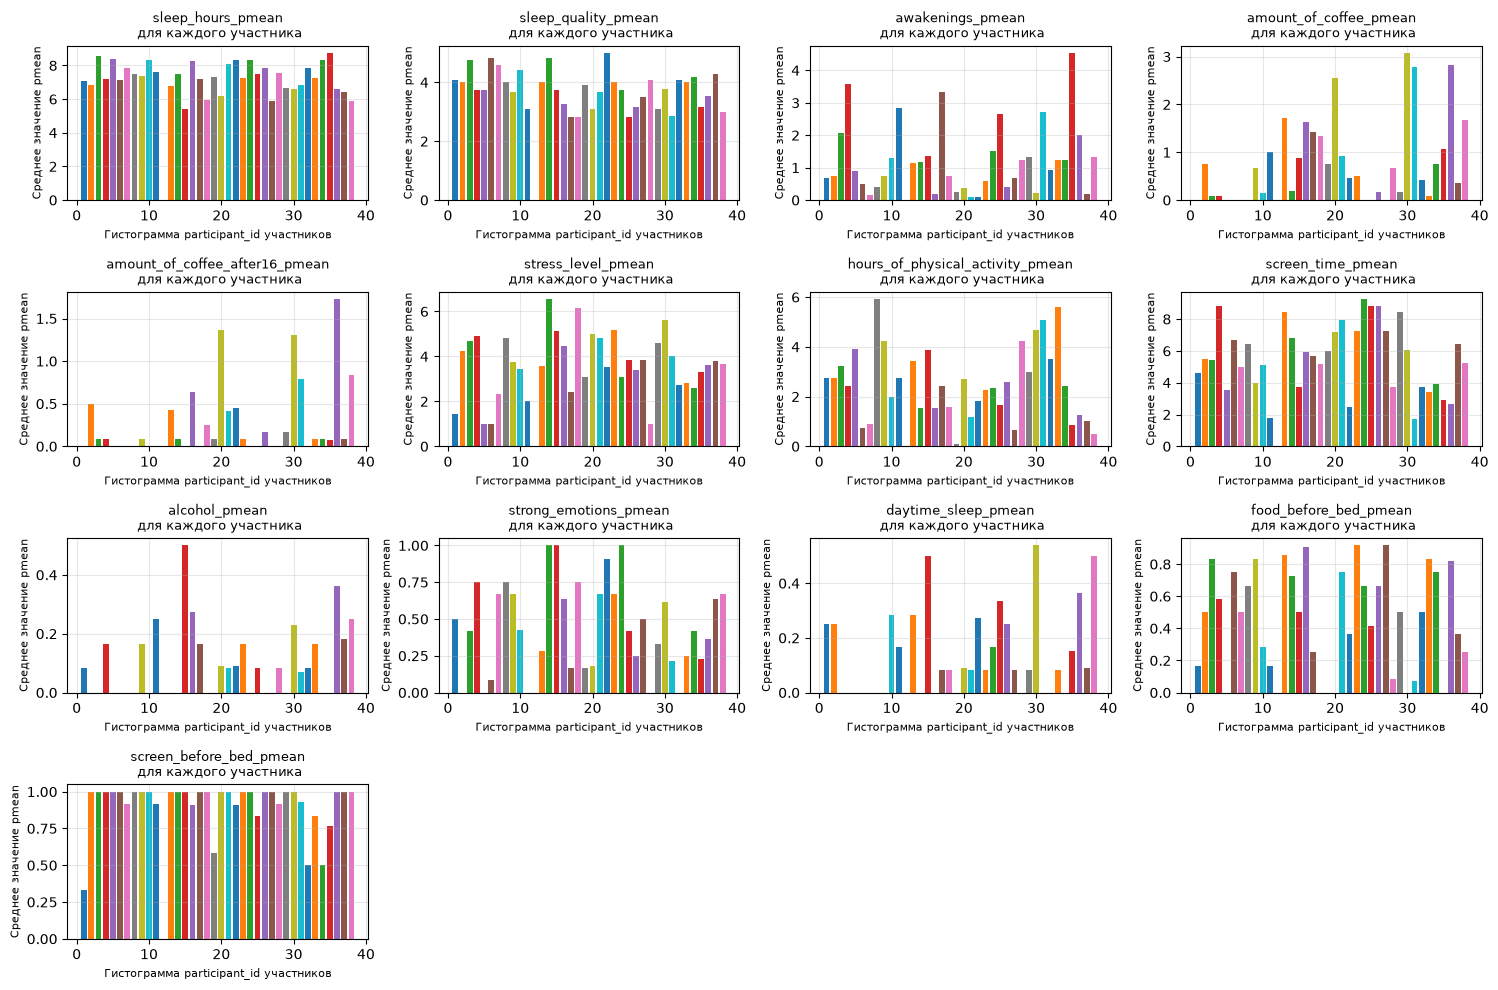

In [18]:
between_cols = [col for col in between_within.columns if "_pmean" in col]

fig, axes = plt.subplots(4, 4, figsize=(15, 10))

for ax, col in zip(axes.flatten(), between_cols):
    for i, group in between_within.groupby(by="participant_id"):
        ax.bar(i, group[col])

    ax.set_title(f"{col}\n для каждого участника", fontsize=9)
    ax.set_xlabel("Гистограмма participant_id участников", fontsize=8)
    ax.set_ylabel("Cреднее значение pmean", fontsize=8)
    
    ax.grid(True, alpha=0.3)
    
for ax in axes.flatten()[len(between_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Анализ индивидуальных средних значений признаков показал наличие существенных различий между участниками по ряду характеристик. Наиболее выраженная межличностная неоднородность наблюдается для количества пробуждений, употребления кофе, уровня стресса, физической активности и экранного времени. В то же время для алкоголя и дневного сна значения у большинства участников близки к нулю, что указывает на низкую распространённость этих характеристик в выборке.

### Визуализация внутриличностной декомпозиции (with_in)

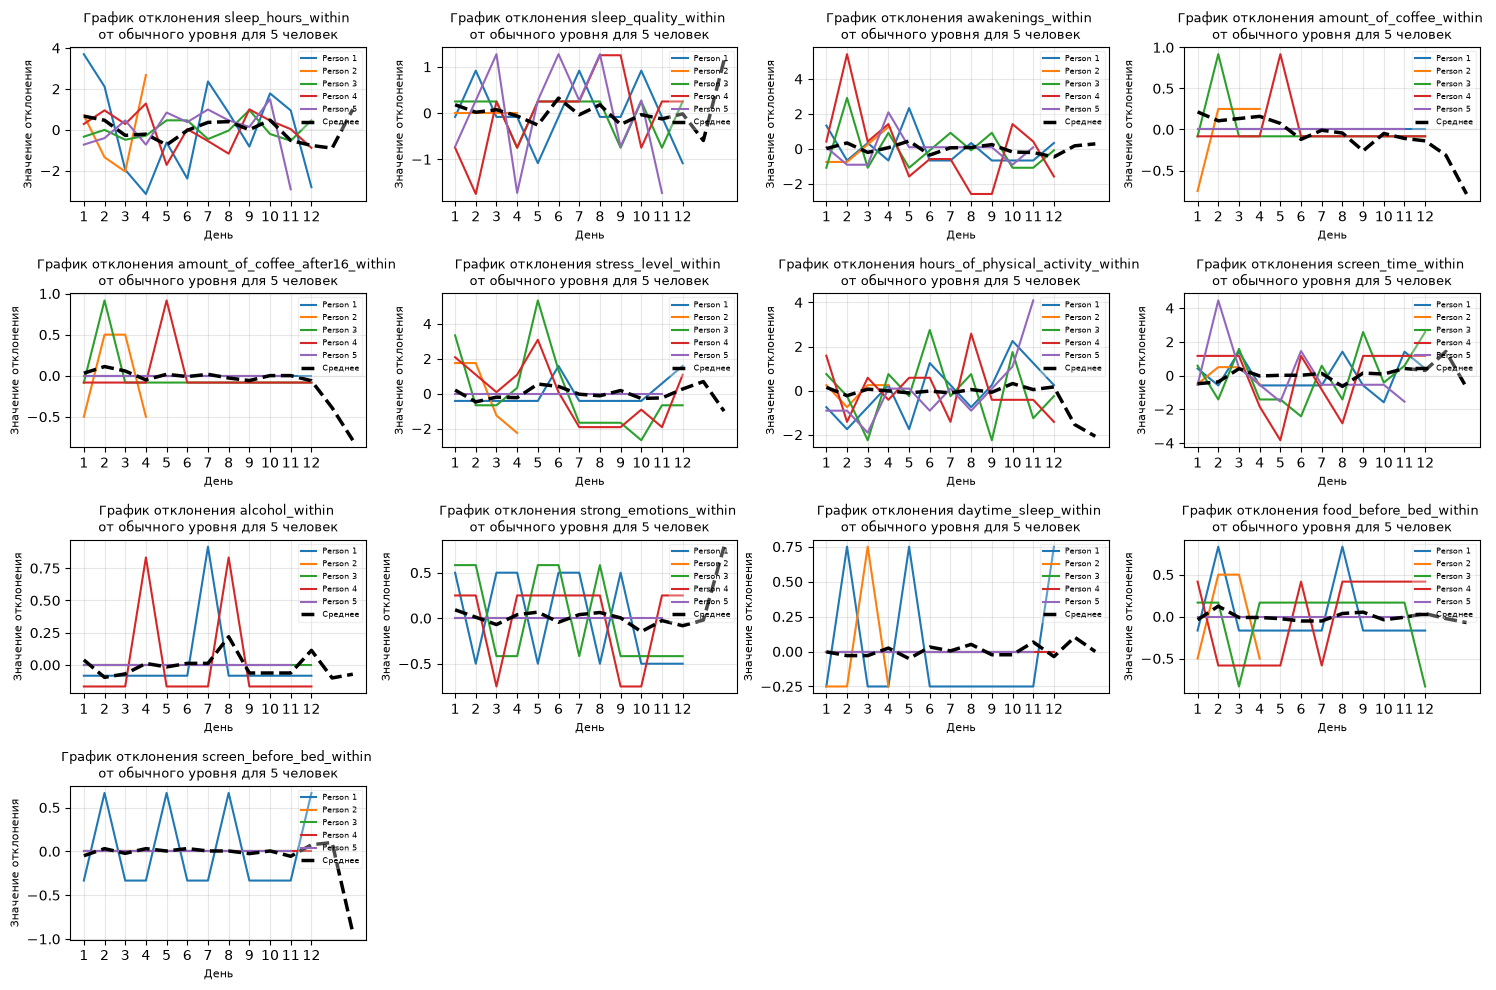

In [19]:
people = sorted(between_within['participant_id'].unique())[:5]

fig, axes = plt.subplots(4, 4, figsize=(15, 10))

for ax, col in zip(axes.flatten(), with_in_cols):
    for person in people:
        days_person = between_within[between_within["participant_id"] == person]["observation_number"].values
        col_person = between_within[between_within["participant_id"] == person][col].values
        ax.plot(days_person, col_person, label=f"Person {person}")
        
    mean_line = between_within.groupby('observation_number')[col].mean()
    ax.plot(mean_line.index, mean_line.values,color='black', lw=2.5, linestyle='--', label='Среднее')
    
    ax.set_title(f"График отклонения {col} \nот обычного уровня для 5 человек", fontsize=9)
    ax.set_xticks(range(1, 13, 1))
    ax.set_xlabel('День', fontsize=8)
    ax.set_ylabel('Значение отклонения', fontsize=8)
    
    ax.legend(fontsize=5.5, loc='upper right', framealpha=0.3)
    
    ax.grid(True, alpha=0.3)

    
for ax in axes.flatten()[len(with_in_cols):]:       
        ax.axis("off")
        
plt.tight_layout()
plt.show()

Графики подтверждают наличие выраженной внутриличностной вариативности для ряда признаков. Особенно заметны изменения продолжительности и качества сна, уровня стресса, физической активности и количества пробуждений. Это подтверждает целесообразность использования within-компонентов признаков для дальнейшего анализа связи между изменениями состояния человека и вероятностью запоминания сновидения.

### Подсчёт долей within и between

In [20]:
share_variance = pd.DataFrame()

for i in time_varying_cols:
    total_variance = np.var(df[i])
    between_variance = np.var(between_within[f"{i}_pmean"])
    within_variance = np.var(between_within[f"{i}_within"])

    share_variance.loc[i, "total_variance"] = total_variance
    share_variance.loc[i, "between_share"] = between_variance / (between_variance + within_variance)
    share_variance.loc[i, "within_share"] = within_variance / (between_variance + within_variance)

share_variance

,total_variance,between_share,within_share
sleep_hours,3.025966,0.219738,0.780262
sleep_quality,1.141199,0.326072,0.673928
awakenings,2.684115,0.452423,0.547577
amount_of_coffee,1.252830,0.640085,0.359915
amount_of_coffee_after16,0.323614,0.563660,0.436340
stress_level,5.261533,0.358262,0.641738
hours_of_physical_activity,3.977170,0.551882,0.448118
screen_time,7.246063,0.620286,0.379714
alcohol,0.086352,0.147773,0.852227
strong_emotions,0.247606,0.351148,0.648852


### Визуализация разложения

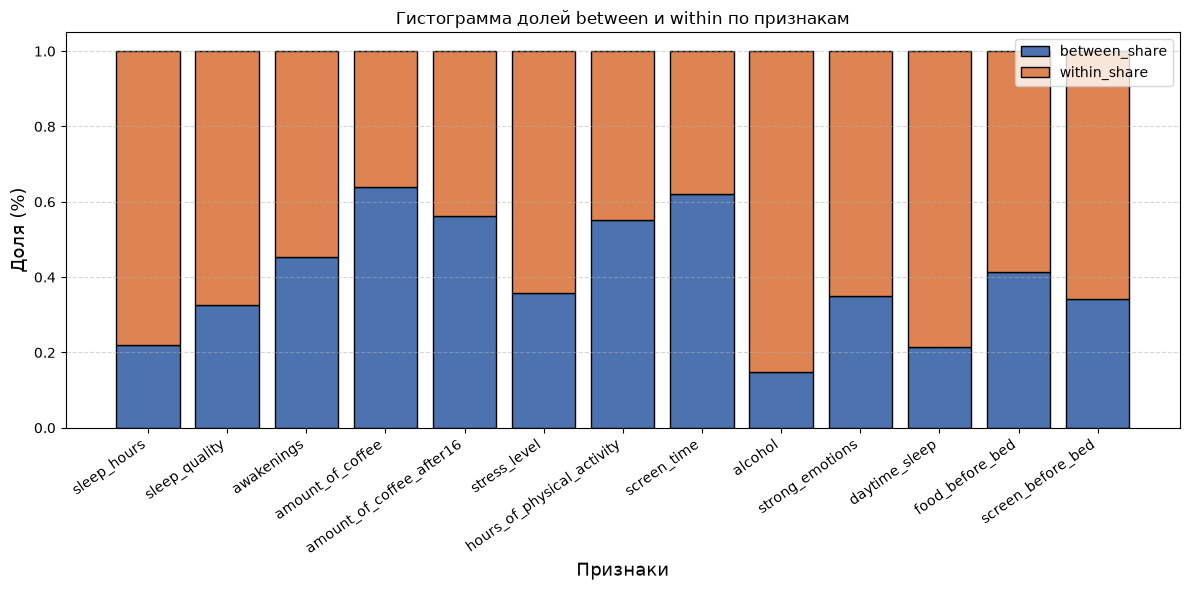

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(share_variance.index, share_variance["between_share"], color="#4C72B0", edgecolor="black")
ax.bar(share_variance.index, share_variance["within_share"], bottom=share_variance["between_share"], color="#DD8452", edgecolor="black")

ax.set_title("Гистограмма долей between и within по признакам")
ax.set_xlabel('Признаки', fontsize=13)
ax.set_ylabel('Доля (%)', fontsize=13)

ax.set_xticks(range(len(share_variance.index)))
ax.set_xticklabels(share_variance.index, rotation=35, ha='right', fontsize=10)

ax.grid(True, alpha=0.5, axis="y", ls="--")

ax.legend(labels=["between_share", "within_share"])

plt.tight_layout()
plt.show()

### Анализ within- и between-вариации признаков

Для оценки структуры панельных данных была рассчитана доля общей дисперсии каждого признака, обусловленная различиями между участниками `between` и изменениями внутри одного участника от дня к дню `within`.

| Признак                    | Интерпретация|
| ---------------------------| ---------------------------------------------------------------------------- |
| sleep_hours                | Признак сильно меняется у одного человека от дня к дню                       |
| sleep_quality              | Преобладает внутриличностная вариативность                                   |
| awakenings                 | Вариативность примерно одинаковая обусловлена различиями между людьми и днями|
| amount_of_coffee           | Сильнее характеризует индивидуальные привычки                                |
| amount_of_coffee_after16   | Небольшое преимущество межличностных различий                                |
| stress_level               | Стресс заметно меняется у одного человека от дня к дню                       |
| hours_of_physical_activity | Вариативность умеренно смещена в сторону различий между людьми               |
| screen_time                | Значительная часть различий связана с индивидуальными привычками             |
| alcohol                    | Высокая within-доля, но общая вариативность очень мала                       |
| strong_emotions            | Эмоциональное состояние заметно меняется от дня к дню                        |
| daytime_sleep              | Сильная внутриличностная вариативность                                       |
| food_before_bed            | Умеренно преобладает внутриличностная вариативность                          |
| screen_before_bed          | Признак заметно меняется у одного человека от дня к дню                      |

### Вывод

Анализ показывает, что для ряда признаков значительная часть вариации возникает внутри одного и того же участника, а не только за счёт различий между участниками. Особенно высокая `within`-вариативность наблюдается для `alcohol` (85.2%), `daytime_sleep` (78.7%) и `sleep_hours` (77.9%), а также для `sleep_quality`, `stress_level`, `strong_emotions` и `screen_before_bed`.

Для целей данного исследования это важно, поскольку задача заключается в изучении связи между состоянием и образом жизни человека в предыдущий день и вероятностью запоминания сновидения на следующее утро. Признаки с высокой `within`-вариативностью позволяют анализировать изменения состояния одного и того же человека от дня к дню.

Признаки с высокой `between` долей, например `amount_of_coffee` и `screen_time`, в большей степени отражают устойчивые индивидуальные различия и привычки участников. Поэтому их можно использовать для анализа межличностных различий.

### Визуалиализация с помощью boxplot для 5 участников для признаков с большей within/between декомпозицией

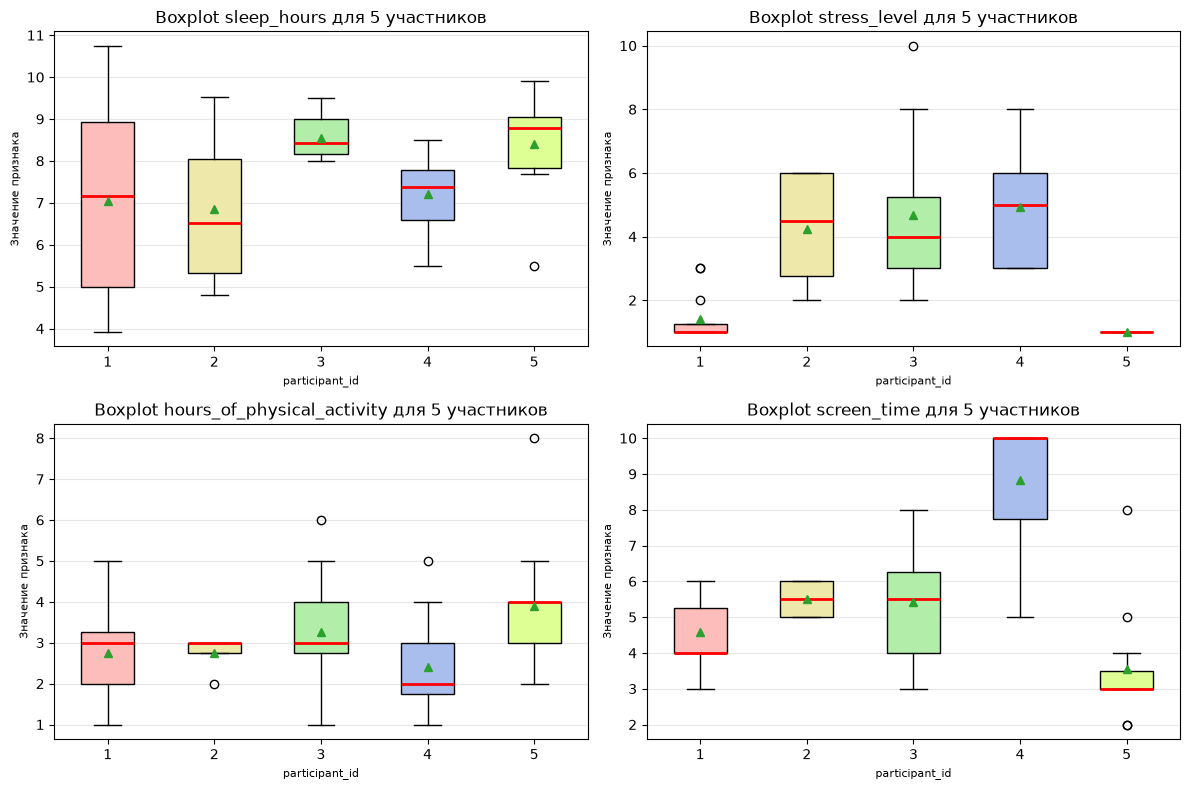

In [22]:
between_within_cols = ["sleep_hours", "stress_level", "hours_of_physical_activity", "screen_time"]
box_colors = ['#fdbdba', "#eee8aa", "#b2eeaa", "#aabeee", "#deff94"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), between_within_cols):
    total_group = []
    for person in people:
        total_group.append(df[df["participant_id"] == person][col].values)
    
    
    ax.set_title(f"Boxplot {col} для 5 участников")
    ax.set_xlabel("participant_id", fontsize=8)
    ax.set_ylabel("Значение признака", fontsize=8)
    
    ax.grid(True, alpha=0.3, axis="y")
    
    bp = ax.boxplot(total_group, patch_artist=True, showmeans=True, medianprops=dict(color="red", lw=2))

    
    for i, color in enumerate(box_colors):
        bp["boxes"][i].set_facecolor(color)
plt.tight_layout()
plt.show()

По графикам видно, что показатели заметно различаются между участниками. Особенно сильно варьируются сон, уровень стресса и экранное время, тогда как физическая активность в большинстве случаев находится примерно в диапазоне 2–4 часов, но также имеет отдельные выбросы.

### Сравнение корреляций между людьми и внутри людей

In [34]:
num_cols = calc_num_cols(df)

num_cols_without2 = [col for col in num_cols if col not in ["sex", "dream_remembered"]]

general_matrix = df[num_cols_without2].corr()
within_corr_matrix = between_within[with_in_cols].corr()
between_corr_matrix = between_within[between_cols].corr()

corr_matrix_list = [general_matrix, between_corr_matrix, within_corr_matrix]
corr_matrix_name = ["General матрица", "Between матрица", "Within матрица"]

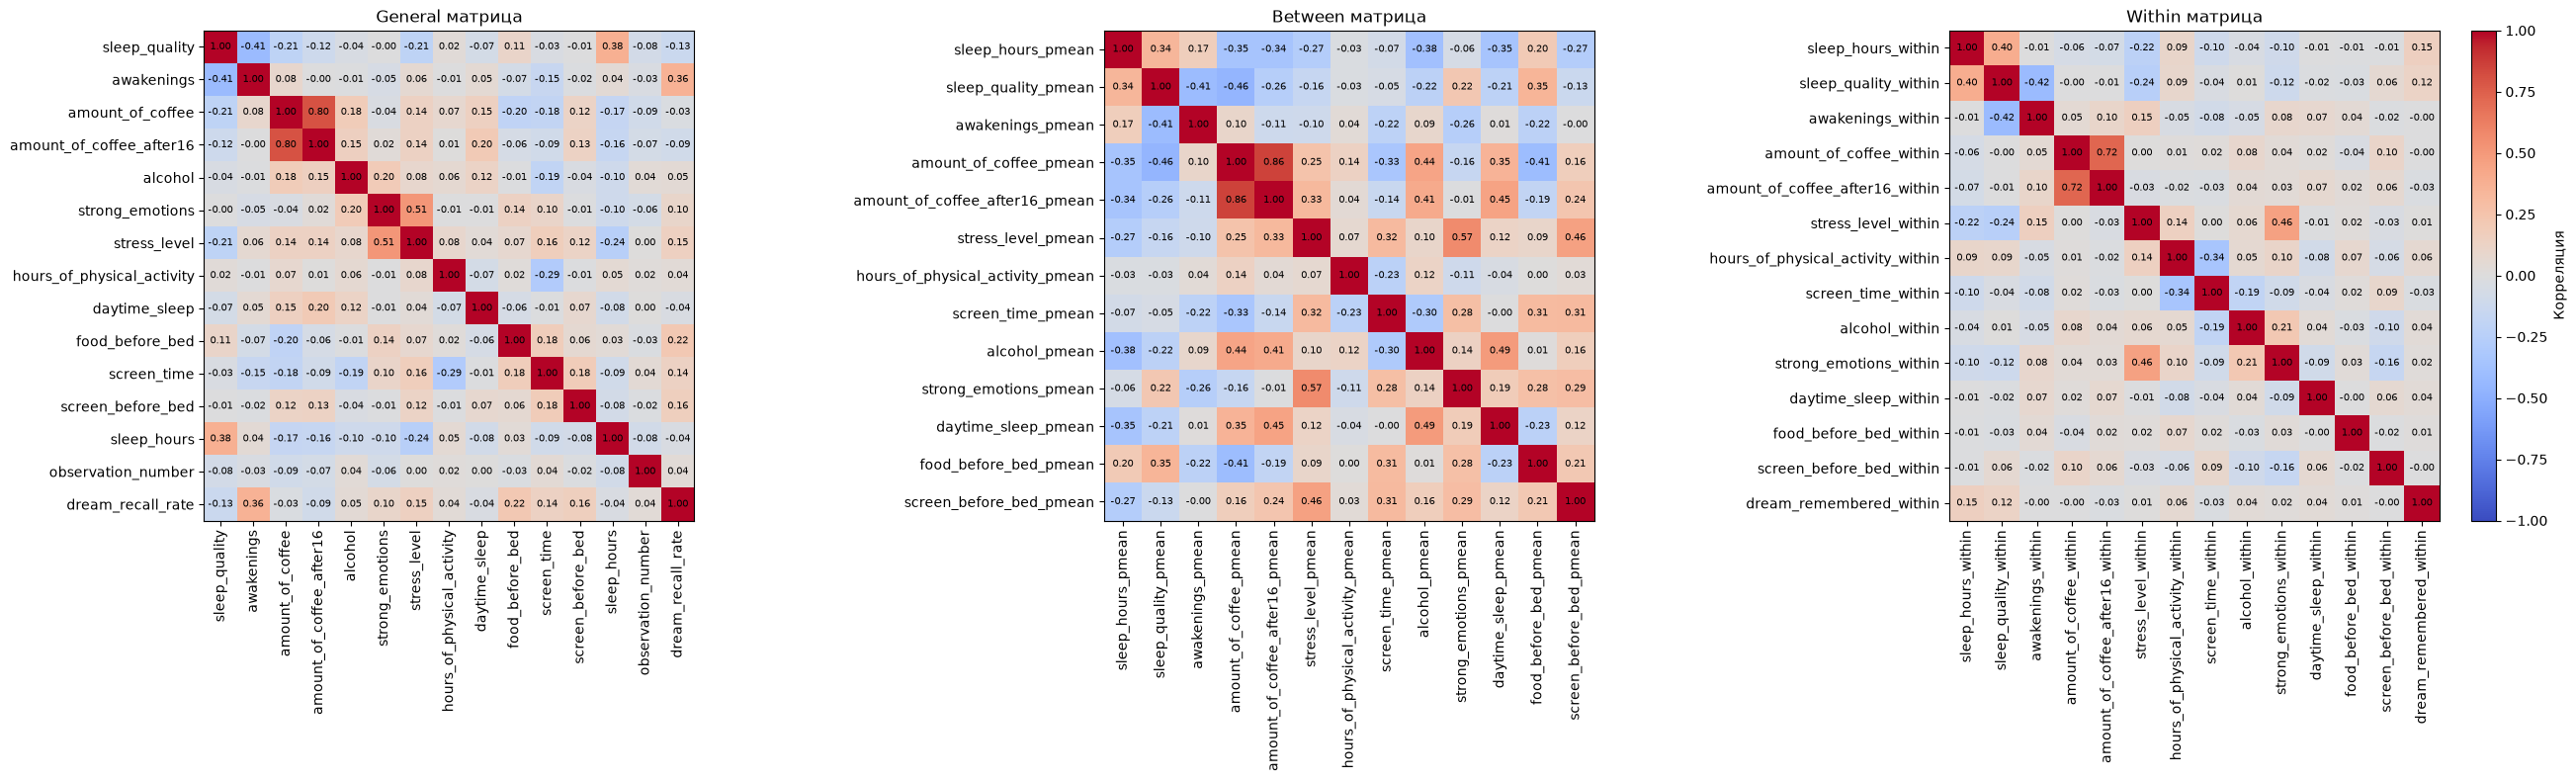

In [35]:
n = len(corr_matrix_list)

fig, axes = plt.subplots(1, n, figsize=(9 * n, 8))

for ax, matrix, name in zip(axes.flatten(), corr_matrix_list, corr_matrix_name):
    
    im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_title(name)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index, fontsize=10)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, fontsize=10, rotation=90)

    for i in range(len(matrix.columns)):
        for j in range(len(matrix.columns)):
            val = matrix.iloc[i, j]
            ax.text(j, i, f"{val:.2f}",  ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Корреляция")

plt.tight_layout()
plt.show()

- Во всех матрицах сохраняется сильная корреляция между признаками amount_of_coffee и amount_of_coffee_after16
- В корреляционной матрице between наблюдает средняя положительная корреляция между strong_emotion_pmean и stress_level_pmean (0.60), alcohol_pmean и daytime_sleep_pmean(0.50), amount_of_coffee(_after16)_pmean и daytime_sleep_pmean(0.45)
- В корреляционной матрице between наблюдает средняя отрицательная корреляция между sleep_quality_pmean и awakenings_pmean (-0.40), alcohol_pmean и sleep_hours_pmean (-0.40), daytime_sleep_mean и sleep_hours_pmean (-0.37)

### Разбор целевой переменной

In [25]:
dream_recall_table = (df.groupby("participant_id").agg(dream_recall_rate=("dream_remembered", "mean"), n_nights=("dream_remembered", "size")).reset_index())

dream_recall_table["dream_recall_rate"] *= 100

dream_recall_table

,participant_id,dream_recall_rate,n_nights
0,1,16.666667,12
1,2,25.000000,4
2,3,41.666667,12
3,4,91.666667,12
4,5,0.000000,11
5,6,50.000000,12
6,7,41.666667,12
7,8,66.666667,12
8,9,41.666667,12
9,10,28.571429,7


In [26]:
dream_recall_table[["dream_recall_rate", "n_nights"]].describe()

,dream_recall_rate,n_nights
count,37.000000,37.000000
mean,43.937706,11.324324
std,21.045582,1.871631
min,0.000000,4.000000
25%,27.272727,11.000000
50%,41.666667,12.000000
75%,58.333333,12.000000
max,91.666667,14.000000


Доля запоминания среди участников варьирует от 0% до 92%, что указывает на выраженные различия между участниками. Это означает, что индивидуальные особенности человека потенциально играют существенную роль в вероятности запоминания сна.

In [27]:
dream_recall_table.loc[dream_recall_table["dream_recall_rate"] == 0]

,participant_id,dream_recall_rate,n_nights
4,5,0.0,11


Участник с participant №5 c 11 записями, единственный не входящий в диапазон от 0 до 100% (невключительно), его within декомпозиция будет равна 0, что следует учесть при дальнейшей работе с внутриличностной декомпозицией

### Проверка корреляции between c целевой переменной `dream_remembered`

In [28]:
between_df = df.groupby(by="participant_id").agg(
    sleep_hours=("sleep_hours", "mean"),
    sleep_quality=("sleep_quality", "mean"),
    awakenings=("awakenings", "mean"),
    stress_level=("stress_level", "mean"),
    hours_of_physical_activity=("hours_of_physical_activity", "mean"),
    screen_time=("screen_time", "mean"),
    strong_emotions=("strong_emotions", "mean"),
    daytime_sleep=("daytime_sleep", "mean"),
    food_before_bed=("food_before_bed", "mean"),
    screen_before_bed=("screen_before_bed", "mean"),
    amount_of_coffee=("amount_of_coffee", "mean"),
    amount_of_coffee_after16=("amount_of_coffee_after16", "mean"),
    alcohol=("alcohol", "mean"),
    dream_mean=("dream_remembered", "mean")
).reset_index(drop=True)

print(f"Размер: {between_df.shape}")
between_df.head(5)

Размер: (37, 14)


,sleep_hours,sleep_quality,awakenings,stress_level,hours_of_physical_activity,screen_time,strong_emotions,daytime_sleep,food_before_bed,screen_before_bed,amount_of_coffee,amount_of_coffee_after16,alcohol,dream_mean
0,7.054167,4.083333,0.666667,1.416667,2.750000,4.583333,0.500000,0.25,0.166667,0.333333,0.000000,0.000000,0.083333,0.166667
1,6.841667,4.000000,0.750000,4.250000,2.750000,5.500000,0.000000,0.25,0.500000,1.000000,0.750000,0.500000,0.000000,0.250000
2,8.537500,4.750000,2.083333,4.666667,3.250000,5.416667,0.416667,0.00,0.833333,1.000000,0.083333,0.083333,0.000000,0.416667
3,7.216667,3.750000,3.583333,4.916667,2.416667,8.833333,0.750000,0.00,0.583333,1.000000,0.083333,0.083333,0.166667,0.916667
4,8.407576,3.727273,0.909091,1.000000,3.909091,3.545455,0.000000,0.00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000


In [29]:
corr_between_target = between_df.corr(method="spearman")
corr_between_target

,sleep_hours,sleep_quality,awakenings,stress_level,hours_of_physical_activity,screen_time,strong_emotions,daytime_sleep,food_before_bed,screen_before_bed,amount_of_coffee,amount_of_coffee_after16,alcohol,dream_mean
sleep_hours,1.000000,0.306587,0.046622,-0.383895,0.005101,-0.162792,-0.078561,-0.360626,0.084465,-0.381912,-0.325093,-0.333823,-0.343088,-0.071085
sleep_quality,0.306587,1.000000,-0.354392,-0.190542,0.016223,-0.080456,0.134311,-0.230631,0.266417,-0.118519,-0.413046,-0.207501,-0.240182,-0.263143
awakenings,0.046622,-0.354392,1.000000,-0.107993,0.187596,-0.205151,-0.191443,0.102736,-0.093991,-0.020667,0.074855,-0.228528,0.058137,0.453335
stress_level,-0.383895,-0.190542,-0.107993,1.000000,0.028478,0.383780,0.549232,0.125781,0.160177,0.486047,0.276672,0.512843,0.153400,0.193812
hours_of_physical_activity,0.005101,0.016223,0.187596,0.028478,1.000000,-0.239008,-0.199632,-0.082889,-0.046811,0.017325,0.019203,-0.068783,0.094484,0.004464
screen_time,-0.162792,-0.080456,-0.205151,0.383780,-0.239008,1.000000,0.270662,0.052644,0.320155,0.460154,-0.260901,0.057826,-0.244893,0.222699
strong_emotions,-0.078561,0.134311,-0.191443,0.549232,-0.199632,0.270662,1.000000,0.125657,0.288743,0.273768,-0.139996,0.100573,0.141801,0.192230
daytime_sleep,-0.360626,-0.230631,0.102736,0.125781,-0.082889,0.052644,0.125657,1.000000,-0.174369,0.171623,0.286032,0.241540,0.319599,-0.032297
food_before_bed,0.084465,0.266417,-0.093991,0.160177,-0.046811,0.320155,0.288743,-0.174369,1.000000,0.206278,-0.240558,0.017320,-0.002512,0.376620
screen_before_bed,-0.381912,-0.118519,-0.020667,0.486047,0.017325,0.460154,0.273768,0.171623,0.206278,1.000000,0.047760,0.219272,-0.029713,0.137405


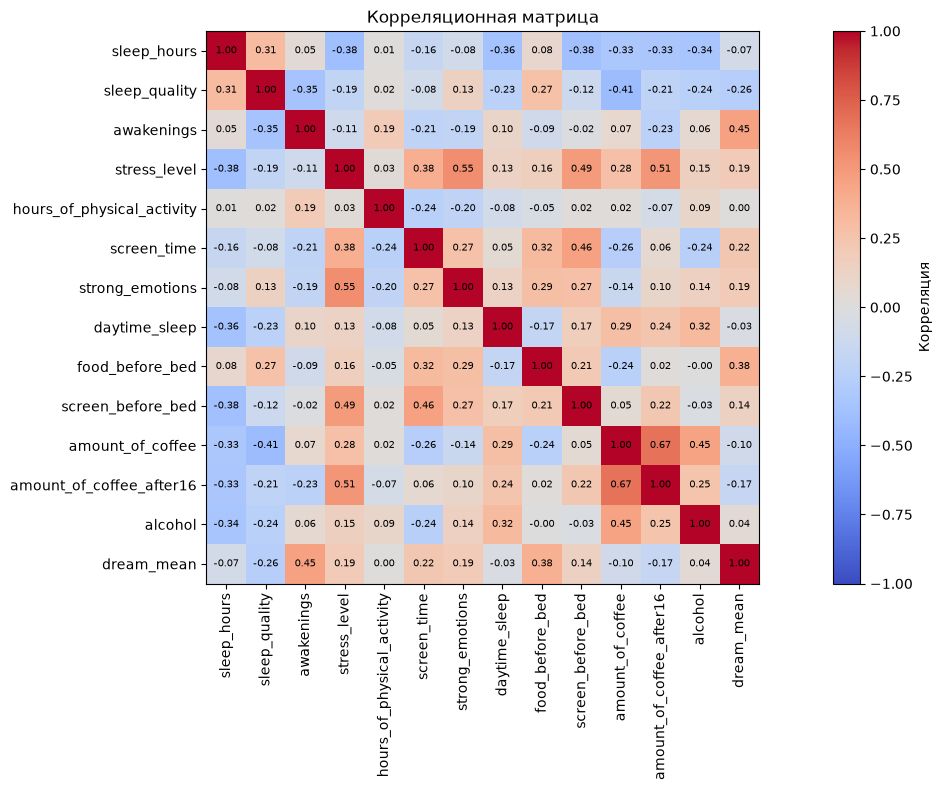

In [30]:
fig, ax = plt.subplots(figsize=(15, 8))

im = ax.imshow(corr_between_target, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_title("Корреляционная матрица")
ax.set_yticks(range(len(corr_between_target.columns)))
ax.set_yticklabels(corr_between_target.columns, fontsize=10, rotation=0)
ax.set_xticks(range(len(corr_between_target.columns)))
ax.set_xticklabels(corr_between_target.columns, fontsize=10, rotation=90)

for i in range(len(corr_between_target.columns)):
    for j in range(len(corr_between_target.columns)):
        val = corr_between_target.iloc[i, j]
        ax.text(j, i, f"{val:.2f}",  ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Корреляция")

plt.tight_layout()
plt.show()

- У участников, которые в среднем чаще просыпаются ночью, наблюдается тенденция к большей доле запоминания снов.
- У участников, которые чаще едят перед сном, наблюдается тенденция к большей средней доле запоминания снов.
- Люди с большей средней продолжительностью экранного времени имеют несколько более высокую долю запоминания снов.
- У участников с более высокой средней субъективной оценкой качества сна доля запоминания снов несколько ниже.

### Проверка корреляции within c целевой переменной `dream_remembered`

In [31]:
df["dream_recall_rate"] = df.groupby("participant_id")["dream_remembered"].transform("mean")

between_within["dream_remembered_within"] = df["dream_remembered"] - df["dream_recall_rate"]
between_within = between_within[between_within["participant_id"] != 5]

In [32]:
with_in_cols.append("dream_remembered_within")

corr_within_target = between_within[with_in_cols].corr(method="spearman")
corr_within_target

,sleep_hours_within,sleep_quality_within,awakenings_within,amount_of_coffee_within,amount_of_coffee_after16_within,stress_level_within,hours_of_physical_activity_within,screen_time_within,alcohol_within,strong_emotions_within,daytime_sleep_within,food_before_bed_within,screen_before_bed_within,dream_remembered_within
sleep_hours_within,1.000000,0.366284,0.133937,-0.092564,-0.063204,-0.207743,0.071006,-0.065495,-0.031727,-0.115985,-0.028628,-0.018186,-0.011593,0.162372
sleep_quality_within,0.366284,1.000000,-0.335688,-0.056101,-0.019067,-0.206590,0.081920,-0.031097,0.013259,-0.121537,0.010609,-0.019958,0.032328,0.116184
awakenings_within,0.133937,-0.335688,1.000000,0.082684,0.007890,0.046863,-0.043985,-0.123927,-0.019470,0.023557,0.092914,0.039127,0.005069,0.051412
amount_of_coffee_within,-0.092564,-0.056101,0.082684,1.000000,0.580276,-0.001699,0.012322,0.077927,0.018465,-0.016118,0.013210,-0.072836,0.122813,-0.036806
amount_of_coffee_after16_within,-0.063204,-0.019067,0.007890,0.580276,1.000000,-0.039330,-0.014962,-0.029364,0.003146,-0.004206,0.030508,-0.022746,0.082623,-0.064996
stress_level_within,-0.207743,-0.206590,0.046863,-0.001699,-0.039330,1.000000,0.144149,0.020960,0.075110,0.467388,-0.002078,0.033994,-0.024240,-0.023189
hours_of_physical_activity_within,0.071006,0.081920,-0.043985,0.012322,-0.014962,0.144149,1.000000,-0.233985,0.041621,0.111725,-0.058863,0.067111,-0.071413,0.053625
screen_time_within,-0.065495,-0.031097,-0.123927,0.077927,-0.029364,0.020960,-0.233985,1.000000,-0.126022,-0.091125,-0.042737,0.031691,0.065200,-0.016843
alcohol_within,-0.031727,0.013259,-0.019470,0.018465,0.003146,0.075110,0.041621,-0.126022,1.000000,0.135173,0.070152,0.019765,-0.116464,0.010456
strong_emotions_within,-0.115985,-0.121537,0.023557,-0.016118,-0.004206,0.467388,0.111725,-0.091125,0.135173,1.000000,-0.068333,0.020569,-0.126163,0.011206


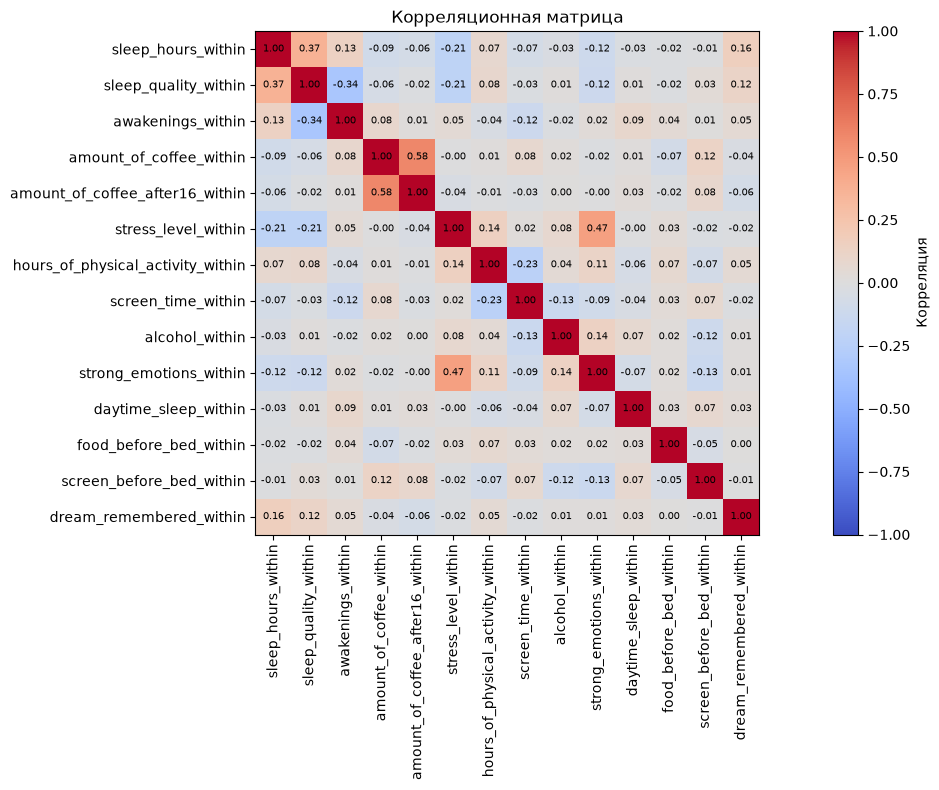

In [33]:
fig, ax = plt.subplots(figsize=(15, 8))

im = ax.imshow(corr_within_target, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_title("Корреляционная матрица")
ax.set_yticks(range(len(corr_within_target.columns)))
ax.set_yticklabels(corr_within_target.columns, fontsize=10, rotation=0)
ax.set_xticks(range(len(corr_within_target.columns)))
ax.set_xticklabels(corr_within_target.columns, fontsize=10, rotation=90)

for i in range(len(corr_within_target.columns)):
    for j in range(len(corr_within_target.columns)):
        val = corr_within_target.iloc[i, j]
        ax.text(j, i, f"{val:.2f}",  ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Корреляция")

plt.tight_layout()
plt.show()

Внутри участников есть небольшая положительная тенденция: в ночи, когда человек спал дольше своего обычного уровня, вероятность запоминания сна также была несколько выше его обычного уровня.

### Таблицу решений по признакам для первой модели

|Признак|Наблюдаемая структура|Решение для первой модели|Обоснование|
|-------|---------------------|-------------------------|-----------|
|age|Constant, только between|raw (для baseline)|Признак не меняется внутри участника, поэтому разложение на within/between невозможно (используется как индивидуальная характеристика участника)|
|sex|Constant, только between|raw (для baseline)|Признак постоянен для участника и представляет межличностное различие|
|sleep_hours|Сильно преобладает within-вариативность (=78%). Between-связь с `dream_mean` слабая (`r = -0.08`), within-связь слабая положительная (`r = 0.16`)|raw (для baseline)|Признак сильно меняется от ночи к ночи, однако явной сильной связи с target ни на одном уровне не обнаружено|
|sleep_quality|Преобладает within-вариативность. Between-связь слабая отрицательная (`r = -0.26`), within-связь слабая положительная (`r = 0.11`)|raw (для baseline)|Наблюдаются слабые разнонаправленные тенденции, поэтому разделение на компоненты пока не даёт достаточно убедочного основания|
|awakenings|Within и between-вариация сопоставимы. Наиболее заметная between-связь с target (`r = 0.45`), within-связь слабая (`rₛ ≈ 0.05`)|raw (для baseline)|Связь преимущественно отражает различия между участниками: люди, которые в среднем чаще просыпаются, имеют тенденцию чаще запоминать сны|
|amount_of_coffee|Значительная between-вариативность; сильно коррелирует с `amount_of_coffee_after16`|raw (для baseline)|Признак отражает индивидуальные привычки, но использование одновременно двух показателей кофе создаёт избыточную информацию|
|amount_of_coffee_after16|Значительная between-вариативность; сильно коррелирует с общим количеством кофе|exclude|Информация частично содержится в `amount_of_coffee`|
|stress_level|Значительная within-вариативность. Between-связь слабая положительная (`r = 0.20`), within-связь практически отсутствует (`r = -0.03`)|raw (для baseline)|Исходный признак оставлен для простой baseline-модели; его коэффициент нельзя интерпретировать отдельно как within- или between-эффект.|
|hours_of_physical_activity|Умеренная between-вариативность. Связь с target практически отсутствует (`r = 0.01` between; `= 0.06` within)|raw (для baseline)|Признак не показывает заметной связи с target, но его можно сохранить как потенциальный предиктор для baseline-модели|
|screen_time|Значительная between-вариативность. Between-связь слабая положительная (`r = 0.23`), within-связь практически отсутствует (`r = -0.02`)|raw (для baseline)|Наблюдаемая тенденция преимущественно относится к различиям между участниками, а не к изменениям экранного времени относительно собственного среднего|
|alcohol|Очень высокая within-доля, но низкая общая распространённость события|exclude|Высокая within-доля обусловлена редкостью признака, а не обязательно содержательной внутриличностной вариативностью|
|strong_emotions|Высокая within-вариативность. Between-связь слабая положительная (`r = 0.20`), within-связь практически отсутствует (`r = 0.01`)|raw (для baseline)|Эмоциональное состояние меняется от дня к дню, однако выраженной связи с target не обнаружено. Сохраняем для baseline, не выделяя отдельный within-компонент|
|daytime_sleep|Высокая within-доля (=79%), но событие относительно редкое. Between-связь практически отсутствует (`r = -0.04`), within-связь очень слабая (`= 0.04`)|raw (для baseline)|Высокая within-доля сама по себе не является доказательством полезности признака, оставить как исходный бинарный признак для baseline|
|food_before_bed|Умеренно преобладает within-вариативность. Between-связь заметная (`r = 0.38`), within-связь практически отсутствует (`r = 0.00`)|raw (для baseline)|Связь наблюдается преимущественно между участниками, а не при изменении поведения относительно собственной нормы. Для нового пользователя без истории доступен только raw.|
|screen_before_bed|Значительная within-вариативность. Between-связь слабая (`r = 0.15`), within-связь практически отсутствует (`= -0.01`)|raw (для baseline)|Признак меняется внутри человека, но явной связи с target не показывает|


In [46]:
# Сохраянем в csv
df.to_csv("../data/processed/after_panel_eda.csv")

between_within.merge(dream_recall_table[["participant_id", "dream_recall_rate"]], on="participant_id", how="left")
between_within.to_csv("../data/processed/between_within.csv")